# RSA Encryption and Classical Factoring Attack

## Goal

This notebook demonstrates how RSA encryption works and why RSA security depends on the difficulty of factoring a large modulus.

The notebook has two connected parts:

1. A basic RSA encryption/decryption demonstration using randomly generated small primes.
2. A toy RSA attack using `n = 21`, which connects directly to the Shor and Grover notebooks in this project.

## Main result

For the toy RSA example:

- `p = 3`
- `q = 7`
- `n = 21`
- public key `(e, n) = (5, 21)`
- private key `(d, n) = (5, 21)`
- message `m = 5`
- ciphertext `c = 17`

After factoring `n = 21` into `3 × 7`, an attacker can reconstruct the private key and decrypt the ciphertext back to `m = 5`.

## Important note

This is an educational toy implementation. It is **not** secure RSA and should not be used for real encryption. Real RSA uses much larger primes, secure padding, and trusted cryptographic libraries.

## 1. Setup

This cell imports the libraries used in the notebook and creates a folder for saved figures.

When this notebook is placed inside a `notebooks/` folder, figures will be saved into `../figures/`.

In [4]:
import math
import random
import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

random.seed(42)

# Save figures to ../figures if the notebook is inside notebooks/.
# Otherwise save to ./figures.
FIGURE_DIR = Path("../figures") if Path.cwd().name == "notebooks" else Path("figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Figures will be saved to: {FIGURE_DIR.resolve()}")

Figures will be saved to: /Users/harrydo/Documents/CS480Q/quantum-rsa-post-quantum-crypto/figures


## 2. Helper Functions

These helper functions implement the basic RSA building blocks.

RSA depends on:

- choosing two prime numbers `p` and `q`
- computing `n = p × q`
- computing Euler's totient `φ(n) = (p - 1)(q - 1)`
- choosing a public exponent `e`
- computing the private exponent `d`, where `d ≡ e⁻¹ mod φ(n)`

Python's built-in `pow(e, -1, phi_n)` computes the modular inverse.

In [5]:
def is_prime(num):
    """
    Return True if num is prime, otherwise False.

    This is a simple trial-division primality check.
    It is fine for this educational notebook, but it is not meant for real cryptography.
    """
    if num < 2:
        return False

    for divisor in range(2, int(math.sqrt(num)) + 1):
        if num % divisor == 0:
            return False

    return True


def generate_prime(min_value, max_value):
    """
    Generate a random prime number in the given range.
    """
    candidate = random.randint(min_value, max_value)

    while not is_prime(candidate):
        candidate = random.randint(min_value, max_value)

    return candidate


def generate_small_rsa_keypair(min_prime=1000, max_prime=5000):
    """
    Generate a small educational RSA keypair.

    Returns:
        Dictionary containing p, q, n, phi_n, e, d
    """
    p = generate_prime(min_prime, max_prime)
    q = generate_prime(min_prime, max_prime)

    while p == q:
        q = generate_prime(min_prime, max_prime)

    n = p * q
    phi_n = (p - 1) * (q - 1)

    e = random.randint(3, phi_n - 1)
    while math.gcd(e, phi_n) != 1:
        e = random.randint(3, phi_n - 1)

    d = pow(e, -1, phi_n)

    return {
        "p": p,
        "q": q,
        "n": n,
        "phi_n": phi_n,
        "e": e,
        "d": d,
    }


def rsa_encrypt_number(message, e, n):
    """
    Encrypt one integer message using RSA.
    """
    if message >= n:
        raise ValueError("Message must be smaller than n.")

    return pow(message, e, n)


def rsa_decrypt_number(ciphertext, d, n):
    """
    Decrypt one integer ciphertext using RSA.
    """
    return pow(ciphertext, d, n)


def rsa_encrypt_text(message, e, n):
    """
    Encrypt a short text message character by character.

    Note:
        This is only for demonstration. Real RSA does not encrypt raw text character by character.
    """
    encoded_message = [ord(char) for char in message]
    ciphertext = [rsa_encrypt_number(char_code, e, n) for char_code in encoded_message]
    return ciphertext


def rsa_decrypt_text(ciphertext, d, n):
    """
    Decrypt a character-by-character RSA ciphertext back into text.
    """
    decoded_values = [rsa_decrypt_number(value, d, n) for value in ciphertext]
    decoded_message = "".join(chr(value) for value in decoded_values)
    return decoded_message


def classical_factor_with_steps(n):
    """
    Factor n using trial division.

    Returns:
        p, q, steps
    """
    steps = 0

    for possible_factor in range(2, math.isqrt(n) + 1):
        steps += 1

        if n % possible_factor == 0:
            p = possible_factor
            q = n // possible_factor
            return p, q, steps

    return None, None, steps

## 3. Basic RSA Encryption and Decryption

This section shows the normal RSA workflow:

1. Generate two primes `p` and `q`.
2. Compute `n = p × q`.
3. Compute `φ(n) = (p - 1)(q - 1)`.
4. Choose a public exponent `e`.
5. Compute the private exponent `d`.
6. Encrypt a message using the public key `(e, n)`.
7. Decrypt using the private key `(d, n)`.

The message used here is `"Hello World"`.

In [6]:
rsa_keys = generate_small_rsa_keypair()

e = rsa_keys["e"]
d = rsa_keys["d"]
n = rsa_keys["n"]

message = "Hello World"
ciphertext = rsa_encrypt_text(message, e, n)
decoded_message = rsa_decrypt_text(ciphertext, d, n)

print("===== Basic RSA Demo =====")
print(f"Public key  (e, n) = ({e}, {n})")
print(f"Private key (d, n) = ({d}, {n})")
print(f"Message: {message}")
print(f"Ciphertext: {ciphertext}")
print(f"Decoded message: {decoded_message}")

assert decoded_message == message

===== Basic RSA Demo =====
Public key  (e, n) = (1769671, 3146713)
Private key (d, n) = (489231, 3146713)
Message: Hello World
Ciphertext: [1792006, 2618608, 315163, 315163, 2920608, 2410563, 893085, 2920608, 952081, 315163, 2361928]
Decoded message: Hello World


## Basic RSA Interpretation

The encrypted values look different from the original text because each character is converted into an integer and encrypted with:

`c = m^e mod n`

Decryption reverses this using:

`m = c^d mod n`

This confirms that the RSA encryption/decryption workflow works for this small educational example.

However, this is still not production-safe RSA because:

1. the primes are too small,
2. the message is encrypted character by character,
3. no secure padding scheme is used,
4. the code is written for learning, not for real security.

## 4. Toy RSA Setup for the Quantum Project

For the Shor and Grover notebooks, this project uses the toy RSA modulus:

`n = 21 = 3 × 7`

This is intentionally small so that the math can be connected to quantum algorithms.

The toy RSA values are:

- `p = 3`
- `q = 7`
- `n = 21`
- `φ(n) = 12`
- `e = 5`
- `d = 5`
- message `m = 5`

Encryption:

`c = 5^5 mod 21 = 17`

Decryption:

`m = 17^5 mod 21 = 5`

In [7]:
toy_p = 3
toy_q = 7
toy_n = toy_p * toy_q
toy_phi = (toy_p - 1) * (toy_q - 1)

toy_e = 5
toy_d = pow(toy_e, -1, toy_phi)

toy_message = 5
toy_ciphertext = rsa_encrypt_number(toy_message, toy_e, toy_n)
toy_decrypted = rsa_decrypt_number(toy_ciphertext, toy_d, toy_n)

print("===== Toy RSA Setup =====")
print(f"p = {toy_p}")
print(f"q = {toy_q}")
print(f"n = p × q = {toy_n}")
print(f"φ(n) = {toy_phi}")
print(f"Public key  = (e, n) = ({toy_e}, {toy_n})")
print(f"Private key = (d, n) = ({toy_d}, {toy_n})")

print("\n===== Toy RSA Encryption / Decryption =====")
print(f"Original message = {toy_message}")
print(f"Ciphertext = {toy_ciphertext}")
print(f"Decrypted message = {toy_decrypted}")

assert toy_ciphertext == 17
assert toy_decrypted == toy_message

===== Toy RSA Setup =====
p = 3
q = 7
n = p × q = 21
φ(n) = 12
Public key  = (e, n) = (5, 21)
Private key = (d, n) = (5, 21)

===== Toy RSA Encryption / Decryption =====
Original message = 5
Ciphertext = 17
Decrypted message = 5


## 5. Classical Factoring Attack

RSA is vulnerable if an attacker can factor the public modulus `n`.

In the toy example, the attacker knows:

`n = 21`

If the attacker finds:

`21 = 3 × 7`

then the attacker can compute:

`φ(n) = (3 - 1)(7 - 1) = 12`

Then the attacker can reconstruct the private exponent:

`d = e⁻¹ mod φ(n) = 5`

After that, the attacker can decrypt the ciphertext.

In [8]:
start_time = time.perf_counter()
recovered_p, recovered_q, factoring_steps = classical_factor_with_steps(toy_n)
end_time = time.perf_counter()

classical_runtime = end_time - start_time

recovered_phi = (recovered_p - 1) * (recovered_q - 1)
recovered_d = pow(toy_e, -1, recovered_phi)
attacker_decrypted = rsa_decrypt_number(toy_ciphertext, recovered_d, toy_n)

print("===== Classical Factoring Attack =====")
print(f"Public modulus n = {toy_n}")
print(f"Recovered factors = {recovered_p}, {recovered_q}")
print(f"Trial division steps = {factoring_steps}")
print(f"Runtime = {classical_runtime:.8f} seconds")

print("\n===== Private Key Recovery =====")
print(f"Recovered φ(n) = {recovered_phi}")
print(f"Recovered private exponent d = {recovered_d}")
print(f"Attacker decrypts ciphertext {toy_ciphertext} to message {attacker_decrypted}")

assert {recovered_p, recovered_q} == {toy_p, toy_q}
assert recovered_d == toy_d
assert attacker_decrypted == toy_message

===== Classical Factoring Attack =====
Public modulus n = 21
Recovered factors = 3, 7
Trial division steps = 2
Runtime = 0.00002704 seconds

===== Private Key Recovery =====
Recovered φ(n) = 12
Recovered private exponent d = 5
Attacker decrypts ciphertext 17 to message 5


## 6. Figure 1: Classical Factoring Cost for Small RSA-Like Moduli

This figure shows how many trial divisions are needed to factor small RSA-like moduli.

The graph is not a real benchmark for large RSA. It is included to visualize the idea that factoring becomes harder as `n` grows.

,p,q,n,Recovered p,Recovered q,Trial divisions
0,3,5,15,3,5,2
1,3,7,21,3,7,2
2,5,7,35,5,7,4
3,7,11,77,7,11,6
4,11,13,143,11,13,10
5,13,17,221,13,17,12
6,17,19,323,17,19,16
7,19,23,437,19,23,18
8,29,31,899,29,31,28
9,37,41,1517,37,41,36


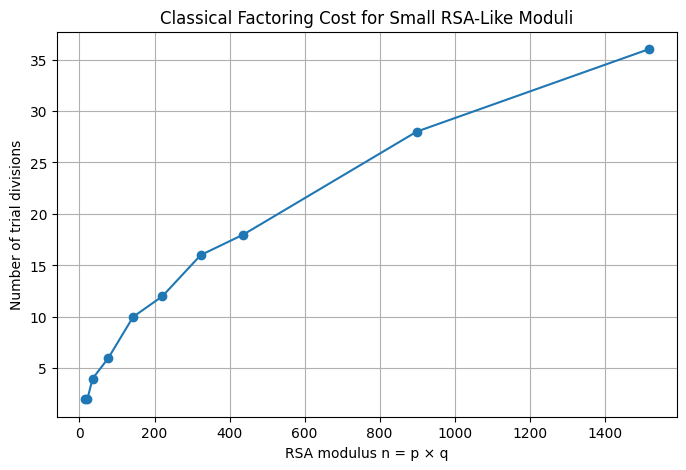

Saved figure to: ../figures/rsa_classical_factoring_cost.png


In [9]:
test_cases = [
    (3, 5),
    (3, 7),      # n = 21, the main toy RSA modulus
    (5, 7),
    (7, 11),
    (11, 13),
    (13, 17),
    (17, 19),
    (19, 23),
    (29, 31),
    (37, 41),
]

classical_results = []

for p_test, q_test in test_cases:
    n_test = p_test * q_test
    fp, fq, steps = classical_factor_with_steps(n_test)

    classical_results.append({
        "p": p_test,
        "q": q_test,
        "n": n_test,
        "Recovered p": fp,
        "Recovered q": fq,
        "Trial divisions": steps,
    })

df_classical = pd.DataFrame(classical_results)
display(df_classical)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_classical["n"], df_classical["Trial divisions"], marker="o")
ax.set_xlabel("RSA modulus n = p × q")
ax.set_ylabel("Number of trial divisions")
ax.set_title("Classical Factoring Cost for Small RSA-Like Moduli")
ax.grid(True)

figure_path = FIGURE_DIR / "rsa_classical_factoring_cost.png"
fig.savefig(figure_path, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {figure_path}")

## 7. Figure 2: Original Factors vs. Recovered Factors

This figure compares the original secret factors with the factors recovered by the classical attacker.

For the toy example, they match exactly:

`p = 3`, `q = 7`

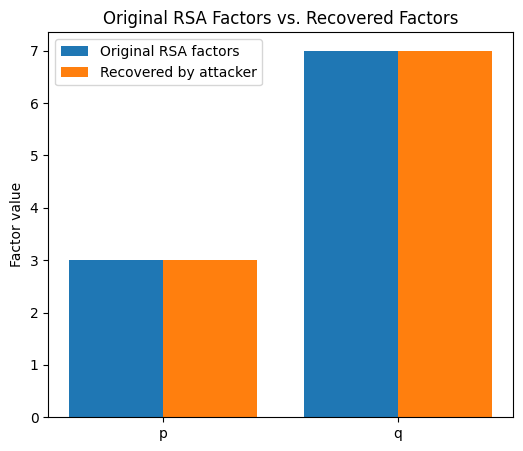

Saved figure to: ../figures/rsa_original_vs_recovered_factors.png


In [10]:
labels = ["p", "q"]
original_values = [toy_p, toy_q]
recovered_values = [recovered_p, recovered_q]

x_positions = list(range(len(labels)))
width = 0.4

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar([x - width / 2 for x in x_positions], original_values, width=width, label="Original RSA factors")
ax.bar([x + width / 2 for x in x_positions], recovered_values, width=width, label="Recovered by attacker")

ax.set_xticks(x_positions)
ax.set_xticklabels(labels)
ax.set_ylabel("Factor value")
ax.set_title("Original RSA Factors vs. Recovered Factors")
ax.legend()

figure_path = FIGURE_DIR / "rsa_original_vs_recovered_factors.png"
fig.savefig(figure_path, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {figure_path}")

## 8. Summary Table

This table summarizes the full RSA toy experiment.

In [11]:
rsa_21_summary = pd.DataFrame([
    {
        "Step": "Toy RSA setup",
        "Input": "p = 3, q = 7",
        "Output": "n = 21",
        "Meaning": "RSA modulus is created from two primes",
    },
    {
        "Step": "Encryption",
        "Input": "m = 5, e = 5, n = 21",
        "Output": f"ciphertext = {toy_ciphertext}",
        "Meaning": "Message is encrypted using the public key",
    },
    {
        "Step": "Classical factoring attack",
        "Input": "n = 21",
        "Output": f"recovered factors = {recovered_p}, {recovered_q}",
        "Meaning": "Attacker factors the public modulus",
    },
    {
        "Step": "Private key recovery",
        "Input": "p = 3, q = 7, e = 5",
        "Output": f"recovered d = {recovered_d}",
        "Meaning": "Factoring n allows private key reconstruction",
    },
    {
        "Step": "Attacker decryption",
        "Input": f"ciphertext = {toy_ciphertext}",
        "Output": f"recovered message = {attacker_decrypted}",
        "Meaning": "The attacker recovers the original plaintext",
    },
])

display(rsa_21_summary)

,Step,Input,Output,Meaning
0,Toy RSA setup,"p = 3, q = 7",n = 21,RSA modulus is created from two primes
1,Encryption,"m = 5, e = 5, n = 21",ciphertext = 17,Message is encrypted using the public key
2,Classical factoring attack,n = 21,"recovered factors = 3, 7",Attacker factors the public modulus
3,Private key recovery,"p = 3, q = 7, e = 5",recovered d = 5,Factoring n allows private key reconstruction
4,Attacker decryption,ciphertext = 17,recovered message = 5,The attacker recovers the original plaintext


## 9. Connection to the Next Notebooks

This notebook provides the RSA baseline for the rest of the project.

The next notebooks use the same toy RSA setup:

- **Shor's algorithm notebook:** factors `N = 21` and recovers `3` and `7`.
- **Grover's algorithm notebook:** searches for the plaintext `m = 5` that satisfies `m^5 mod 21 = 17`.
- **ML-KEM notebook:** demonstrates a post-quantum key establishment method that does not rely on integer factorization.

The full project story is:

`RSA → Classical Factoring → Shor → Grover → ML-KEM`

## 10. Limitations

This notebook is intentionally simple.

Important limitations:

1. The RSA numbers are very small.
2. The implementation does not use secure padding.
3. The text example encrypts each character separately.
4. Trial division is only used for educational visualization.
5. This notebook does not break real RSA.
6. Real RSA should be implemented using trusted cryptographic libraries.

The purpose is to build intuition before studying quantum attacks on RSA.